C:\Users\CastroM\AppData\Local\Temp\ipykernel_12324\465925264.py:39: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  rect = plt.Rectangle(
C:\Users\CastroM\AppData\Local\Temp\ipykernel_12324\465925264.py:59: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  spacer = plt.Rectangle(
C:\Users\CastroM\AppData\Local\Temp\ipykernel_12324\465925264.py:69: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  rect = plt.Rectangle(


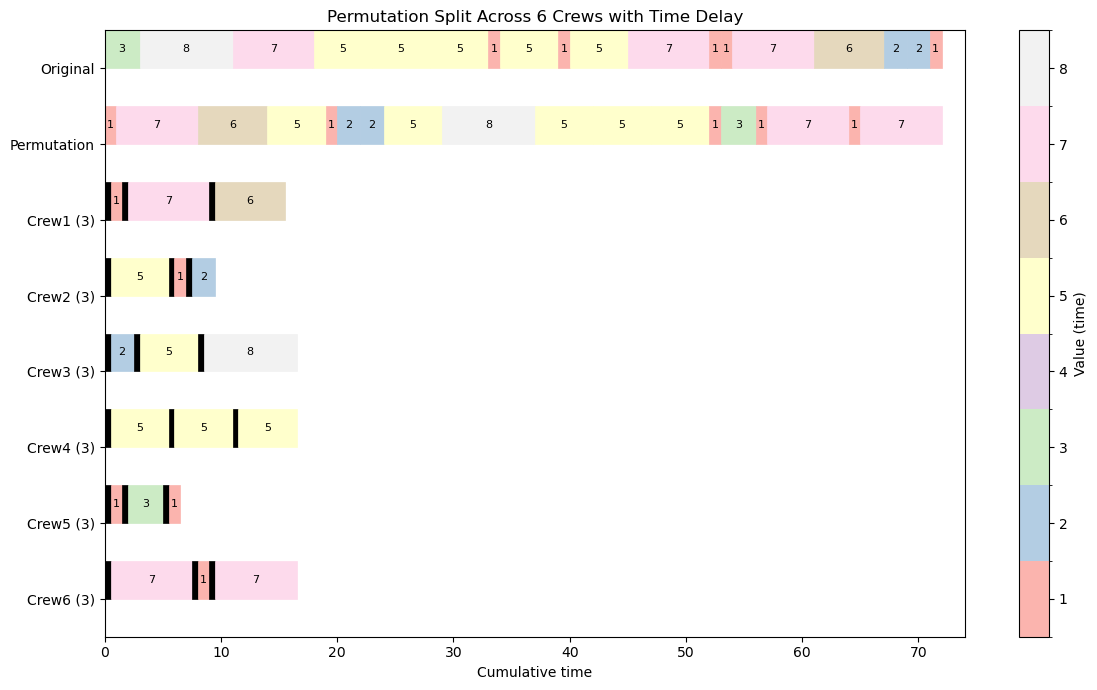

In [5]:
import random
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# -----------------------------
# 1. Generate data (18 values)
# -----------------------------
nums = [random.randint(1, 8) for _ in range(18)]

# Create permutation
perm = nums.copy()
random.shuffle(perm)

# Split into 6 crews (3 values each)
crew1 = perm[0:3]
crew2 = perm[3:6]
crew3 = perm[6:9]
crew4 = perm[9:12]
crew5 = perm[12:15]
crew6 = perm[15:18]

# -----------------------------
# 2. Colormap (pastel categories)
# -----------------------------
cmap = plt.get_cmap('Pastel1', 8)
bounds = np.arange(1, 10) - 0.5
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# -----------------------------
# 3. Plot setup
# -----------------------------
fig, ax = plt.subplots(figsize=(12, 7))

# Standard row (no spacers)
def draw_row(values, y):
    x = 0
    for v in values:
        rect = plt.Rectangle(
            (x, y), v, 1,
            color=cmap(v-1),
            edgecolor='black',
            linewidth=0.5
        )
        ax.add_patch(rect)

        # label
        ax.text(x + v/2, y + 0.5, str(v),
                ha='center', va='center', fontsize=8)

        x += v
    return x

# Crew row (with light blue spacer blocks)
def draw_crew_row(values, y):
    x = 0
    for v in values:
        # spacer block (light blue)
        spacer = plt.Rectangle(
            (x, y), 0.5, 1,
            color='black',#'lightblue',
            edgecolor='black',
            linewidth=0.5
        )
        ax.add_patch(spacer)
        x += 0.5

        # actual value block
        rect = plt.Rectangle(
            (x, y), v, 1,
            color=cmap(v-1),
            edgecolor='black',
            linewidth=0.5
        )
        ax.add_patch(rect)

        # label only on value block
        ax.text(x + v/2, y + 0.5, str(v),
                ha='center', va='center', fontsize=8)

        x += v
    return x

# -----------------------------
# 4. Draw rows
# -----------------------------
w1 = draw_row(nums, 5)
w2 = draw_row(perm, 3)

w3 = draw_crew_row(crew1, 1)
w4 = draw_crew_row(crew2, -1)
w5 = draw_crew_row(crew3, -3)
w6 = draw_crew_row(crew4, -5)
w7 = draw_crew_row(crew5, -7)
w8 = draw_crew_row(crew6, -9)

max_width = max(w1, w2, w3, w4, w5, w6, w7, w8)

# -----------------------------
# 5. Colorbar
# -----------------------------
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax, ticks=range(1, 9))
cbar.set_label("Value (time)")

# -----------------------------
# 6. Axes
# -----------------------------
ax.set_xlim(0, max_width + 2)
ax.set_ylim(-10, 6)

ax.set_yticks([5, 3, 1, -1, -3, -5, -7, -9])
ax.set_yticklabels([
    "Original",
    "Permutation",
    "Crew1 (3)",
    "Crew2 (3)",
    "Crew3 (3)",
    "Crew4 (3)",
    "Crew5 (3)",
    "Crew6 (3)"
])

ax.set_xlabel("Cumulative time")
ax.set_title("Permutation Split Across 6 Crews with Time Delay")

plt.tight_layout()
plt.show()